In [31]:
# Matplotlib 
# the individual plot area that containes the x-axis & y-axis
# for x-axis one type data, for 2d graph need two type data x-axis and y-axis, 3d graph need three type data x-axis, y-axis, z-axis
# we also make multiple small graph
# matplotlib provide stateful( pyplot style) functions operate on the current figure & axis (plt.plot())
# onject oriented uses explitcit figure & axes objects for grater control 
# prefer the object oriented style for resuable & complex plots
# label the x-axis & y-axis
# use descriptive labels for plots

# we use line plot when we want to show linear relation between two data
# we use scater plot when we want to show random relation between two data

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

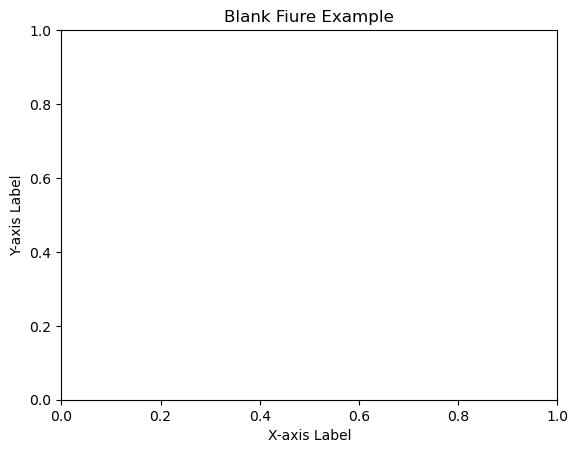

In [3]:
fig, ax = plt.subplots() # object oriented workflow
# lables axes
ax.set_title("Blank Fiure Example")
ax.set_xlabel("X-axis Label")
ax.set_ylabel("Y-axis Label")

# save to PNG
fig.savefig("blank_plot.png",dpi=100)
plt.show()

In [4]:
# Line & Scatter Plots Basics
# Line plots use for small amount of points and Scatter plot use for high amount of points

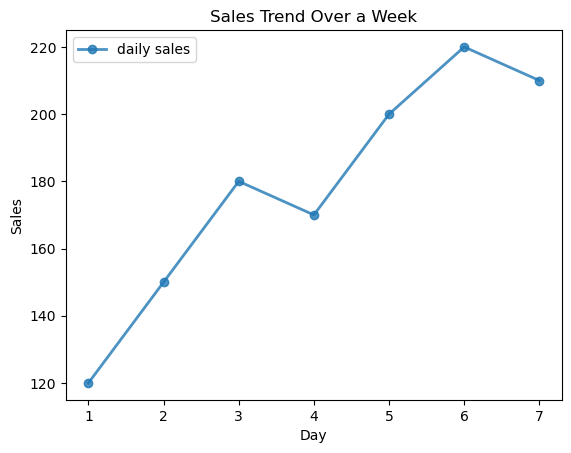

In [10]:
# Sample data for line plot
days = [1,2,3,4,5,6,7]
sales=[120,150,180,170,200,220,210]

plt.plot(days,sales,
    marker='o',
    linewidth=2,
    alpha=0.8, # transparency
    label="daily sales")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Sales Trend Over a Week")
plt.legend() # legend show as side of figure
plt.show()

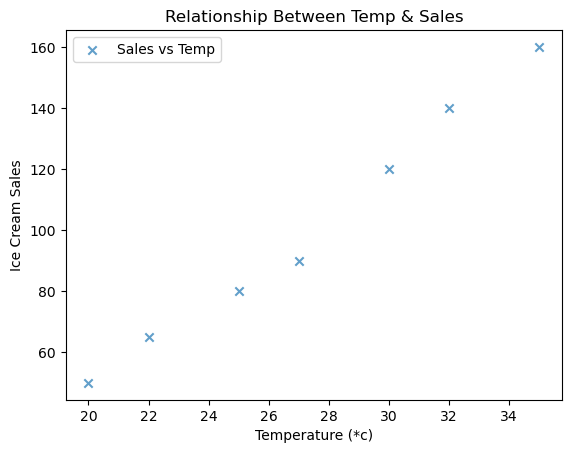

In [11]:
# sample data for Scatter plot
temperature = [20,22,25,27,30,32,35]
ice_cream_sales=[50,65,80,90,120,140,160]
plt.scatter(temperature,ice_cream_sales,
            alpha = 0.7,
            marker = 'x',
            label="Sales vs Temp")
plt.xlabel("Temperature (*c)")
plt.ylabel("Ice Cream Sales")
plt.title("Relationship Between Temp & Sales")
plt.legend()
plt.show()

In [24]:
df = pd.read_csv("./files/ecommerce_sales_analytics_5000.csv",parse_dates=["order_date"])
df = df.sample(n=100)

Text(0, 0.5, 'Total Revenue')

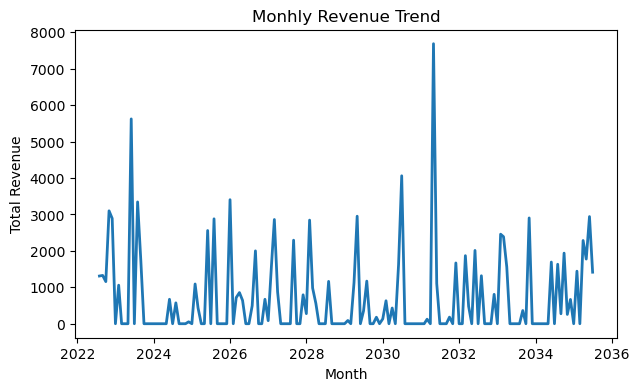

In [25]:
# line plot - monthly revenue trend
monthly_revenue = (df
                   .set_index("order_date")["revenue"]
                   .resample('ME')
                   .sum()
                  )
fid,ax = plt.subplots(figsize = (7,4))
ax.plot(monthly_revenue.index,monthly_revenue.values,linewidth=2)

ax.set_title("Monhly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
# explanation: line connects revenue over time and show growth or decline clearly

Text(0, 0.5, 'Revenue')

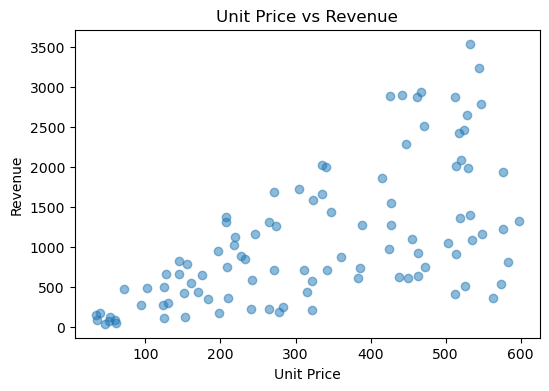

In [30]:
# Scatter plot - Discoun vs revenue
fig,ax = plt.subplots(figsize=(6,4))
ax.scatter(df["unit_price"],df["revenue"],alpha= 0.5)
ax.set_title("Unit Price vs Revenue")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Revenue")

# each point = one order and transparency (alpha) helps with overlapping points

In [33]:
# Bar charts in matplotlib- simple, grouped...
# bar charts use show data in the form of bar
# it show effectiveness when data is grouped

Text(0, 0.5, 'Total Revenue')

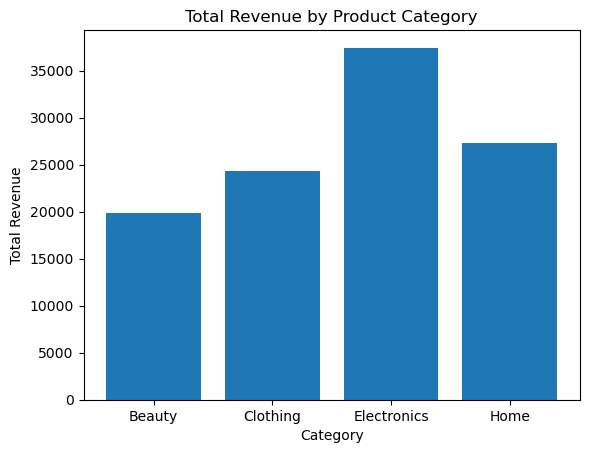

In [36]:
# simple bar chat - revenue by product category
category_revenue = df.groupby("product_category")["revenue"].sum()

fig,ax = plt.subplots()
ax.bar(category_revenue.index,category_revenue.values)

ax.set_title("Total Revenue by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue")

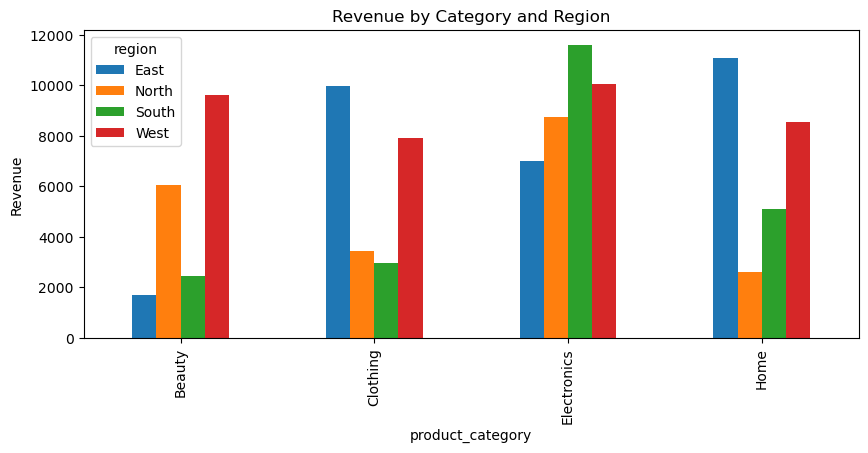

In [37]:
# grouped bar chart - revenue by category & region
grouped = df.groupby(["product_category","region"])["revenue"].sum().unstack()

grouped.plot(kind="bar",figsize=(10,4))
plt.title("Revenue by Category and Region")
plt.ylabel("Revenue")
plt.show()

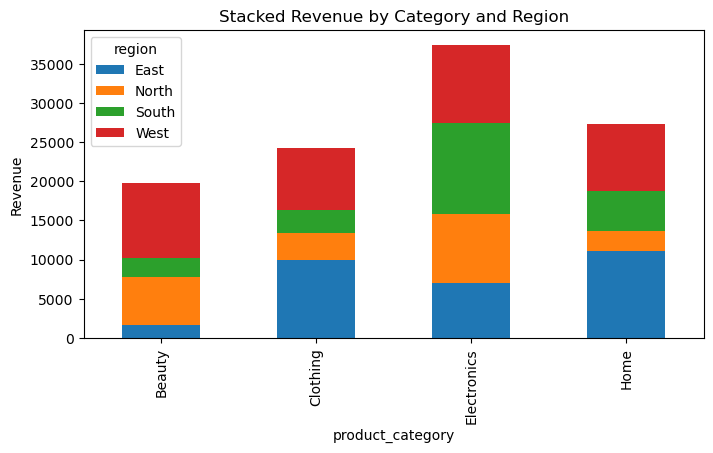

In [39]:
# stacked bar chart
grouped.plot(kind="bar",stacked=True,figsize=(8,4))
plt.title("Stacked Revenue by Category and Region")
plt.ylabel("Revenue")
plt.show()

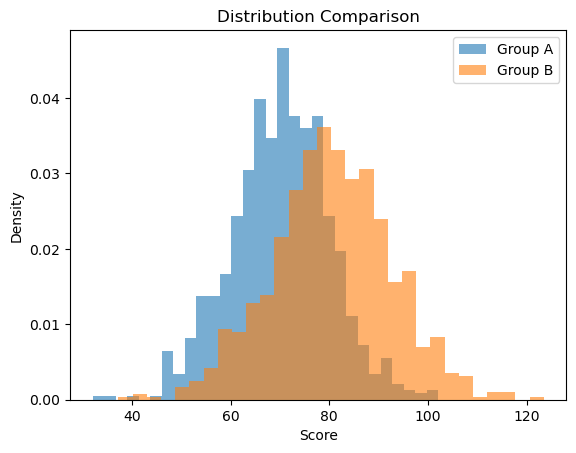

In [62]:
# Histograms & Density Plots, to judge frequency of data
group_a = np.random.normal(70,10,1000) # mean, standard deviation, number of random sample
group_b= np.random.normal(80,12,1000)

plt.hist(group_a,bins = 30,density=True,
         alpha = 0.6, label="Group A")
plt.hist(group_b,bins = 30,density=True,
         alpha = 0.6, label="Group B")

plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution Comparison")
plt.legend()
plt.show()

In [60]:
# use working dataset
df = pd.read_csv("./files/ecommerce_sales_analytics_5000.csv",parse_dates=["order_date"])
df = df.sample(n=1000)

Text(0, 0.5, 'Frequency')

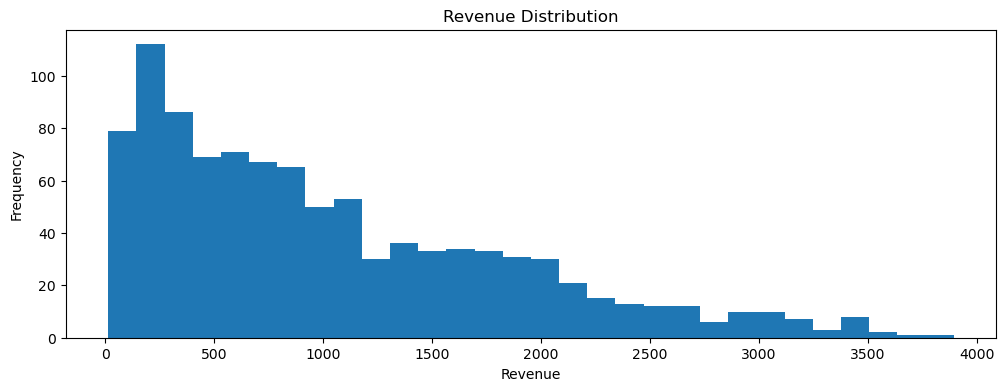

In [50]:
# Histogram - Revenue Distribution
fig,ax = plt.subplots(figsize=(12,4))
ax.hist(df["revenue"],bins=30)

ax.set_title("Revenue Distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Frequency")

Text(0, 0.5, 'Density')

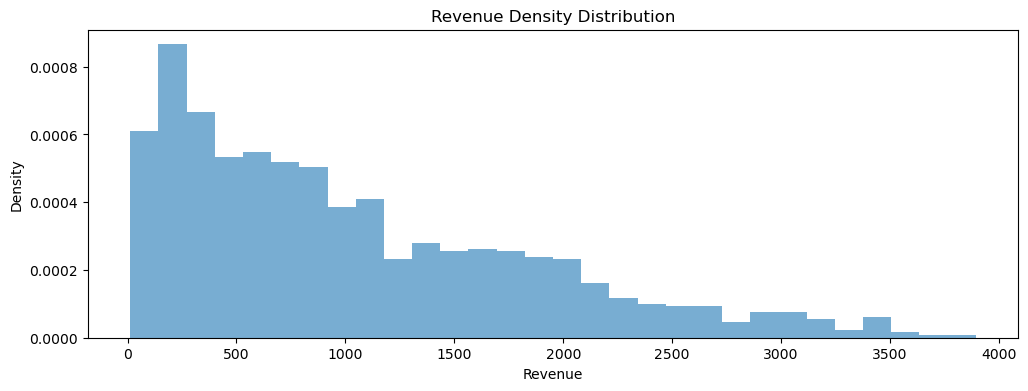

In [54]:
# density plot
fid,ax = plt.subplots(figsize=(12,4))
ax.hist(df["revenue"],bins=30,density=True,alpha=0.6)

ax.set_title("Revenue Density Distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Density")

Text(0.5, 1.0, 'Revenue Comparison')

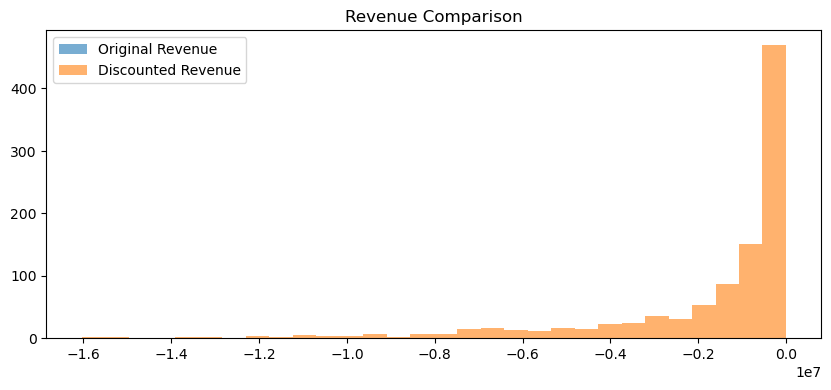

In [61]:
# overlay two histogram (comparison) - revenue vs discounted revenue
discounted_revenue = df["revenue"]*(1 - df["revenue"])

fig,ax = plt.subplots(figsize=(10,4))
ax.hist(df["revenue"],bins=30, alpha=0.6, label="Original Revenue")
ax.hist(discounted_revenue,bins=30,alpha=0.6, label="Discounted Revenue")

ax.legend()
ax.set_title("Revenue Comparison")